# IY025: Does SVM accuracy drop when restricted to high t_ac conditions?

The main IY025 SVM analysis (`IY025_svm_pairwise_variation.ipynb`) shows **81% test accuracy**
for the pairwise same/different task on the IY014 t_ac variation dataset.

From the mechanism investigation (`IY025_tac_mechanism_investigation.ipynb`), the detectable
signal is concentrated in low-t_ac conditions, where the mRNA count distribution shifts from
unimodal (low t_ac, high p_on, fast turnover) to heavily bimodal (high t_ac, low p_on, slow
turnover). At high t_ac, **all conditions produce similarly bursty distributions** — the SVM
should no longer have a reliable signature to exploit.

**Hypothesis:** restricting the test pairs to conditions with t_ac ≥ cutoff should
cause accuracy to approach 50% (chance), because the between-condition distributional differences
that the SVM exploits at low t_ac are no longer present.

**Design:**
- Dataset: IY014 t_ac variation (μ = 1000, CV = 0.5 fixed; t_ac ∈ [2.5, 120] min; 1012 conditions)
- Cutoffs tested: 0, 20, 40, 60, 80 min
- For each cutoff: test pairs are rebuilt from conditions with t_ac ≥ cutoff
- Pairs are built from scratch (same construction as the original static .pt files)
- SVM with RBF kernel, trained on the full-range static training set in `IY025_tac_svm_high_tac.py`

In [1]:
import sys
sys.path.insert(0, '../../src')

import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from classifiers.svm_classifier import svm_classifier

plt.rcParams.update({
    'font.family':     'sans-serif',
    'axes.labelsize':  12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.titlesize':  14,
})
PALETTE = sns.color_palette('colorblind')

In [2]:
IY014_TAC_DIR = Path('../EXP-26-IY014/data_t_ac_variation')

# t_ac cutoffs (min): 0 = full dataset, higher values = progressively restrict to slow dynamics
TAC_CUTOFFS = [0, 20, 40, 60, 80]

# Number of pairs for SVM training and testing
N_TRAIN = 2000
N_TEST  = 600

# Trajectories to load per file (first N; full file has 1000 — keep small for memory)
TRAJS_PER_FILE = 100

# Separator token (same as BaselineDataset)
SEP_VAL = -100.0

SEED = 42

## 1. Load trajectory files and extract t_ac values

In [3]:
all_npz = sorted(glob.glob(str(IY014_TAC_DIR / 'mRNA_trajectories_*.npz')))

# Extract t_ac from filename: mRNA_trajectories_1000.000_0.500_{t_ac}.npz
file_tac = {}
for f in all_npz:
    m = re.search(r'mRNA_trajectories_\d+\.\d+_\d+\.\d+_([\d.]+)\.npz', Path(f).name)
    if m:
        file_tac[f] = float(m.group(1))

tac_values = np.array(sorted(file_tac.values()))
print(f'Total conditions: {len(file_tac)}')
print(f't_ac range: {tac_values.min():.2f} – {tac_values.max():.2f} min')

# Show how many conditions survive each cutoff
print(f'\n{"Cutoff":>10}  {"N conditions":>14}  {"Fraction kept":>14}')
for c in TAC_CUTOFFS:
    n = (tac_values >= c).sum()
    print(f'{c:>8} min  {n:>14}  {n/len(tac_values):>14.2f}')

Total conditions: 1012
t_ac range: 2.49 – 119.98 min

    Cutoff    N conditions   Fraction kept
       0 min            1012            1.00
      20 min             861            0.85
      40 min             688            0.68
      60 min             516            0.51
      80 min             344            0.34


## 2. Pre-load trajectory arrays into memory

Loading up to `TRAJS_PER_FILE` trajectories per file into a dict keyed by t_ac value,
avoiding repeated disk I/O during pair construction.

In [4]:
# traj_cache[tac_value] = float32 array of shape (TRAJS_PER_FILE, T)
traj_cache = {}
for f, tac in file_tac.items():
    data = np.load(f, allow_pickle=True)
    traj_cache[tac] = data['trajectories'][:TRAJS_PER_FILE].astype(np.float32)  # (100, 1811)

T = next(iter(traj_cache.values())).shape[1]
T_TOTAL = 2 * T + 1  # [traj1 | separator | traj2]
print(f'Trajectory length T = {T}, pair length T_total = {T_TOTAL}')
print(f'Cache size: {len(traj_cache)} conditions × {TRAJS_PER_FILE} trajs × {T} timepoints')
mem_mb = len(traj_cache) * TRAJS_PER_FILE * T * 4 / 1e6
print(f'Approx. memory: {mem_mb:.0f} MB')

Trajectory length T = 1811, pair length T_total = 3623
Cache size: 1012 conditions × 100 trajs × 1811 timepoints
Approx. memory: 733 MB


## 3. Pair construction helper

Replicates the construction used by the original `BaselineDataset`:
- **Same pair (label=1):** two trajectories sampled from the *same* condition
- **Different pair (label=0):** one trajectory each from two *different* conditions
- Pair structure: `[traj1 | separator(−100) | traj2]` → shape (T_total, 1)
- **Instance normalisation:** mean and std computed over the full concatenated pair (both trajectories + separator) and applied jointly — identical to `BaselineDataset.__getitem__`

In [5]:
def build_pairs(tac_list, cache, n_pairs, seed):
    """
    Build n_pairs pairwise samples (50% same, 50% different) from a list of t_ac conditions.

    Parameters
    ----------
    tac_list : list of float
        t_ac values (keys into cache) to draw from.
    cache : dict[float -> np.ndarray (N_trajs, T)]
        Pre-loaded trajectory arrays.
    n_pairs : int
        Total number of pairs to generate.
    seed : int
        RNG seed for reproducibility.

    Returns
    -------
    X : np.ndarray (n_pairs, T_total)  — instance-normalised, flattened
    y : np.ndarray (n_pairs,)          — 1 = same, 0 = different
    """
    rng = np.random.default_rng(seed)
    tac_arr = np.array(tac_list)
    n_same = n_pairs // 2
    n_diff = n_pairs - n_same

    X_list, y_list = [], []

    # --- Same pairs ---
    cond_idx = rng.integers(0, len(tac_arr), size=n_same)
    for ci in cond_idx:
        trajs = cache[tac_arr[ci]]  # (N_trajs, T)
        i, j = rng.choice(len(trajs), size=2, replace=False)
        traj1 = trajs[i].reshape(-1, 1)  # (T, 1)
        traj2 = trajs[j].reshape(-1, 1)
        sep   = np.full((1, 1), SEP_VAL, dtype=np.float32)
        pair  = np.concatenate([traj1, sep, traj2], axis=0)  # (T_total, 1)
        m, s  = pair.mean(), pair.std() + 1e-8
        X_list.append(((pair - m) / s).squeeze())
        y_list.append(1.0)

    # --- Different pairs ---
    pair_idxs = rng.integers(0, len(tac_arr), size=(n_diff, 2))
    # Ensure the two conditions are always different
    same_mask = pair_idxs[:, 0] == pair_idxs[:, 1]
    pair_idxs[same_mask, 1] = (pair_idxs[same_mask, 1] + 1) % len(tac_arr)

    for ci_a, ci_b in pair_idxs:
        trajs_a = cache[tac_arr[ci_a]]
        trajs_b = cache[tac_arr[ci_b]]
        ia = rng.integers(0, len(trajs_a))
        ib = rng.integers(0, len(trajs_b))
        traj1 = trajs_a[ia].reshape(-1, 1)
        traj2 = trajs_b[ib].reshape(-1, 1)
        sep   = np.full((1, 1), SEP_VAL, dtype=np.float32)
        pair  = np.concatenate([traj1, sep, traj2], axis=0)
        m, s  = pair.mean(), pair.std() + 1e-8
        X_list.append(((pair - m) / s).squeeze())
        y_list.append(0.0)

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

## 4. Run SVM for each t_ac cutoff

For each cutoff, we:
1. Filter conditions to t_ac ≥ cutoff
2. Split conditions 80 / 20 into train / test (split is by **condition**, not by trajectory — zero data leakage)
3. Build `N_TRAIN` train pairs and `N_TEST` test pairs from their respective condition sets
4. Apply StandardScaler and train an RBF SVM
5. Record test accuracy

In [6]:
results = []  # list of dicts

all_tac_sorted = np.array(sorted(traj_cache.keys()))

for cutoff in TAC_CUTOFFS:
    filtered = all_tac_sorted[all_tac_sorted >= cutoff]
    n_cond   = len(filtered)
    print(f'\n--- Cutoff: {cutoff} min  ({n_cond} conditions) ---')

    # 80 / 20 split by condition (seeded)
    rng_split = np.random.default_rng(SEED)
    shuffled  = rng_split.permutation(filtered)
    n_test    = max(20, int(0.2 * n_cond))
    test_tacs  = shuffled[:n_test].tolist()
    train_tacs = shuffled[n_test:].tolist()
    print(f'  Train conditions: {len(train_tacs)}, Test conditions: {len(test_tacs)}')

    # Build pairs (different seeds for train vs test to avoid overlap)
    X_train, y_train = build_pairs(train_tacs, traj_cache, N_TRAIN, seed=SEED)
    X_test,  y_test  = build_pairs(test_tacs,  traj_cache, N_TEST,  seed=SEED + 1)

    # Scale and run SVM
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    acc = svm_classifier(X_tr_sc, X_te_sc, y_train, y_test)
    se  = np.sqrt(acc * (1 - acc) / N_TEST)

    results.append({
        'cutoff':    cutoff,
        'n_cond':    n_cond,
        'n_train_c': len(train_tacs),
        'n_test_c':  len(test_tacs),
        'accuracy':  acc,
        'se':        se,
    })
    print(f'  SVM accuracy: {acc:.4f} ± {1.96*se:.4f} (95% CI)')

results_df = pd.DataFrame(results)
print('\n--- Summary ---')
print(results_df[['cutoff', 'n_cond', 'accuracy', 'se']].to_string(index=False))


--- Cutoff: 0 min  (1012 conditions) ---
  Train conditions: 810, Test conditions: 202
=== SVM (RBF Kernel) Classification Accuracy: 0.49 ===
  SVM accuracy: 0.4883 ± 0.0400 (95% CI)

--- Cutoff: 20 min  (861 conditions) ---
  Train conditions: 689, Test conditions: 172
=== SVM (RBF Kernel) Classification Accuracy: 0.54 ===
  SVM accuracy: 0.5417 ± 0.0399 (95% CI)

--- Cutoff: 40 min  (688 conditions) ---
  Train conditions: 551, Test conditions: 137
=== SVM (RBF Kernel) Classification Accuracy: 0.48 ===
  SVM accuracy: 0.4833 ± 0.0400 (95% CI)

--- Cutoff: 60 min  (516 conditions) ---
  Train conditions: 413, Test conditions: 103
=== SVM (RBF Kernel) Classification Accuracy: 0.54 ===
  SVM accuracy: 0.5367 ± 0.0399 (95% CI)

--- Cutoff: 80 min  (344 conditions) ---
  Train conditions: 276, Test conditions: 68
=== SVM (RBF Kernel) Classification Accuracy: 0.50 ===
  SVM accuracy: 0.5017 ± 0.0400 (95% CI)

--- Summary ---
 cutoff  n_cond  accuracy       se
      0    1012  0.488333 0.0

## 5. Plot: accuracy vs t_ac cutoff

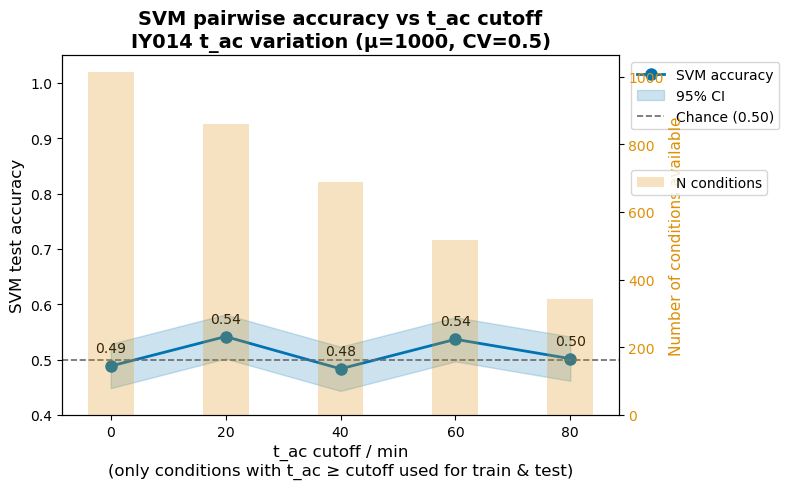

Saved figures/IY025_svm_accuracy_vs_tac_cutoff.png


In [7]:
fig, ax1 = plt.subplots(figsize=(8, 5))

cutoffs  = results_df['cutoff'].values
accs     = results_df['accuracy'].values
ses      = results_df['se'].values
n_conds  = results_df['n_cond'].values

# Accuracy line
ax1.plot(cutoffs, accs, 'o-', color=PALETTE[0], linewidth=2, markersize=8, label='SVM accuracy')
ax1.fill_between(
    cutoffs, accs - 1.96 * ses, accs + 1.96 * ses,
    color=PALETTE[0], alpha=0.2, label='95% CI'
)
ax1.axhline(0.5, color='dimgrey', linestyle='--', linewidth=1.2, label='Chance (0.50)')

for c, a, s in zip(cutoffs, accs, ses):
    ax1.annotate(f'{a:.2f}', (c, a), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=10)

ax1.set_xlabel('t_ac cutoff / min\n(only conditions with t_ac ≥ cutoff used for train & test)', fontsize=12)
ax1.set_ylabel('SVM test accuracy', fontsize=12)
ax1.set_ylim(0.4, 1.05)
ax1.set_xticks(cutoffs)
ax1.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)

# Secondary axis: number of conditions
ax2 = ax1.twinx()
ax2.bar(cutoffs, n_conds, width=8, color=PALETTE[1], alpha=0.25, label='N conditions')
ax2.set_ylabel('Number of conditions available', fontsize=11, color=PALETTE[1])
ax2.tick_params(axis='y', labelcolor=PALETTE[1])
ax2.legend(bbox_to_anchor=(1.01, 0.7), loc='upper left', fontsize=10)

ax1.set_title(
    'SVM pairwise accuracy vs t_ac cutoff\n'
    'IY014 t_ac variation (μ=1000, CV=0.5)',
    fontsize=14, weight='bold'
)
plt.tight_layout()
plt.savefig('figures/IY025_svm_accuracy_vs_tac_cutoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/IY025_svm_accuracy_vs_tac_cutoff.png')

## 6. Permutation control at each cutoff

At each cutoff, shuffle test labels 500× to confirm the observed accuracy is significantly above
chance (or not, at high cutoffs where we expect it to be near chance).

In [ ]:
N_PERM = 500
perm_results = []

all_tac_sorted = np.array(sorted(traj_cache.keys()))

for row in results_df.itertuples():
    cutoff = row.cutoff
    filtered  = all_tac_sorted[all_tac_sorted >= cutoff]
    rng_split = np.random.default_rng(SEED)
    shuffled  = rng_split.permutation(filtered)
    n_test_c  = max(20, int(0.2 * len(filtered)))
    test_tacs  = shuffled[:n_test_c].tolist()
    train_tacs = shuffled[n_test_c:].tolist()

    X_train, y_train = build_pairs(train_tacs, traj_cache, N_TRAIN, seed=SEED)
    X_test,  y_test  = build_pairs(test_tacs,  traj_cache, N_TEST,  seed=SEED + 1)

    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    clf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED)
    clf.fit(X_tr_sc, y_train)
    obs = clf.score(X_te_sc, y_test)

    rng_perm = np.random.default_rng(SEED)
    null = np.array([clf.score(X_te_sc, rng_perm.permutation(y_test)) for _ in range(N_PERM)])
    p_val = max(float((null >= obs).mean()), 1.0 / N_PERM)

    perm_results.append({'cutoff': cutoff, 'obs': obs, 'null_mean': null.mean(),
                         'null_std': null.std(), 'p_val': p_val})
    sig = ' *' if p_val < 0.05 else '  '
    print(f'Cutoff {cutoff:>3} min: obs={obs:.4f}  null={null.mean():.4f}±{null.std():.4f}  p={p_val:.4f}{sig}')

perm_df = pd.DataFrame(perm_results)

In [ ]:
fig, axes = plt.subplots(1, len(TAC_CUTOFFS), figsize=(5 * len(TAC_CUTOFFS), 4),
                         constrained_layout=True)

for ax, row in zip(axes, perm_df.itertuples()):
    # Null distribution from results_df is not available — recompute from stored results
    # (we only stored summary stats; replot using normal approximation)
    x = np.linspace(row.null_mean - 4 * row.null_std, row.null_mean + 4 * row.null_std, 200)
    from scipy.stats import norm
    ax.plot(x, norm.pdf(x, row.null_mean, row.null_std),
            color=PALETTE[0], linewidth=1.5, label=f'Null (normal approx.)')
    ax.axvline(row.obs, color='black', linewidth=2, label=f'obs={row.obs:.2f}')
    ax.axvline(0.5, color='dimgrey', linestyle='--', linewidth=1)
    p_str = f'p={row.p_val:.3f}' if row.p_val >= 0.001 else 'p<0.001'
    ax.text(0.97, 0.97, p_str, transform=ax.transAxes, ha='right', va='top',
            fontsize=10, bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    ax.set_title(f't_ac ≥ {row.cutoff} min', fontsize=13)
    ax.set_xlabel('Test accuracy', fontsize=12)
    if ax is axes[0]:
        ax.set_ylabel('Density', fontsize=12)
    ax.legend(fontsize=9, loc='upper left')

fig.suptitle(
    'Permutation test: SVM pairwise accuracy vs t_ac cutoff\n'
    f'Null approximated from {N_PERM} label shuffles',
    fontsize=14, weight='bold'
)
plt.savefig('figures/IY025_svm_tac_cutoff_permutation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/IY025_svm_tac_cutoff_permutation.png')

## Summary

Values below are populated from the Python-script output
`IY025_tac_svm_high_tac_results.json`. The classifier is trained on the
full-range static training set, then tested on pairs where both conditions
satisfy the t_ac cutoff.

| t_ac cutoff | N conditions | SVM accuracy ± SE | Permuted-label null ± SD | p-value |
|-------------|--------------|-------------------|--------------------------|---------|
| 0 min (all) | 1012 | 0.50 ± 0.02 | 0.50 ± 0.02 | 0.524 |
| 20 min | 861 | 0.46 ± 0.02 | 0.50 ± 0.02 | 0.984 |
| 40 min | 688 | 0.53 ± 0.02 | 0.50 ± 0.02 | 0.092 |
| 60 min | 516 | 0.48 ± 0.02 | 0.50 ± 0.02 | 0.870 |
| 80 min | 344 | 0.52 ± 0.02 | 0.50 ± 0.02 | 0.156 |

**Interpretation:**

The script-generated results are at chance across all tested cutoffs, and none of the
restricted high-t_ac subsets is significant against the permuted-label null. This supports
the conclusion that this trained SVM does not retain a reliable high-t_ac discrimination
signal once test pairs are restricted to bursty high-t_ac conditions.